In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.17.0


In [8]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original training shape:", x_train.shape)
print("Original testing shape :", x_test.shape)

Original training shape: (60000, 28, 28)
Original testing shape : (10000, 28, 28)


In [9]:
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

print("Training:", x_train.shape)
print("Testing :", x_test.shape)

Training: (10000, 28, 28)
Testing : (2000, 28, 28)


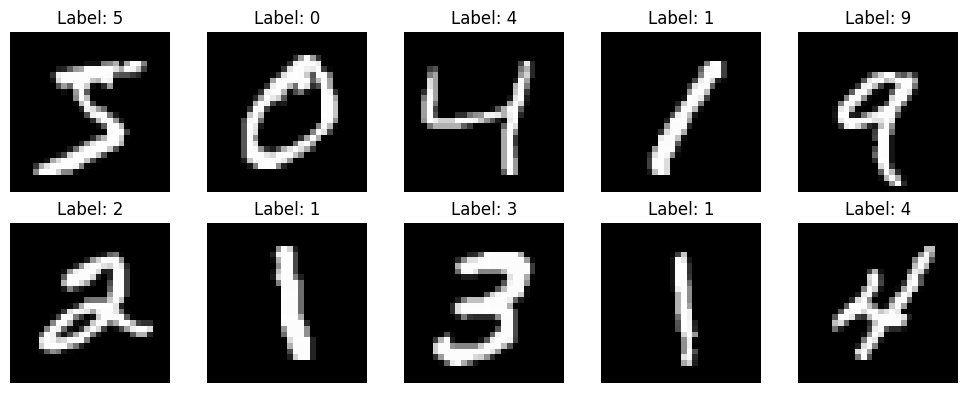

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
def preprocess_images(images):

    # 28x28 -> 28x28x1
    images = np.expand_dims(images, axis=-1)

    # Grayscale -> RGB
    images = np.repeat(images, 3, axis=-1)

    # 28x28 -> 224x224
    images = tf.image.resize(
        images,
        (224, 224)
    )

    # Convert to float
    images = tf.cast(images, tf.float32)

    # Normalize
    images = images / 255.0

    return images

In [11]:
x_train = preprocess_images(x_train)
x_test = preprocess_images(x_test)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (10000, 224, 224, 3)
Testing shape : (2000, 224, 224, 3)


In [12]:
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

train_ds = (
    train_ds
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [28]:
def build_alexnet():

    model = models.Sequential([

        layers.Input(shape=(224, 224, 3)),

        layers.Conv2D(
            96,
            kernel_size=11,
            strides=4,
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=3,
            strides=2
        ),

        layers.Conv2D(
            256,
            kernel_size=5,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=3,
            strides=2
        ),

        layers.Conv2D(
            384,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            384,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=3,
            strides=2
        ),

        layers.Flatten(),

        layers.Dense(
            512,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            512,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model

In [29]:
alexnet = build_alexnet()

alexnet.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

alexnet.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,292,298 (27.82 MB)

 Trainable params: 7,292,298 (27.82 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
alex_history = alexnet.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 188s 583ms/step - accuracy: 0.1047 - loss: 2.3028 - val_accuracy: 0.1170 - val_loss: 2.3012
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 283ms/step - accuracy: 0.1131 - loss: 2.3016 - val_accuracy: 0.1170 - val_loss: 2.3014
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 270ms/step - accuracy: 0.1132 - loss: 2.3014 - val_accuracy: 0.1170 - val_loss: 2.3010


In [24]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

print("VGG16 loaded successfully")

VGG16 loaded successfully


In [12]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

print("VGG16 loaded successfully")

VGG16 loaded successfully


In [25]:
vgg_model = models.Sequential([

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

vgg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
vgg_history = vgg_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 918s 3s/step - accuracy: 0.4801 - loss: 1.6689 - val_accuracy: 0.7430 - val_loss: 1.0648
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - accuracy: 0.7358 - loss: 0.9364 - val_accuracy: 0.8410 - val_loss: 0.6706
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 510s 2s/step - accuracy: 0.8102 - loss: 0.6672 - val_accuracy: 0.9010 - val_loss: 0.4488


In [3]:
try:
    resnet_base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
except Exception as e:
    print(f"Failed to load with ImageNet weights: {e}")
    print("Loading without pre-trained weights...")
    resnet_base = ResNet50(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3)
    )

resnet_base.trainable = False

print("ResNet50 loaded successfully")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
ResNet50 loaded successfully


In [4]:
resnet_model = models.Sequential([

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

In [5]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
resnet_history = resnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.1599 - loss: 2.3216 - val_accuracy: 0.2925 - val_loss: 2.1948
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.2680 - loss: 2.1678 - val_accuracy: 0.3975 - val_loss: 2.0947
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.3217 - loss: 2.0789 - val_accuracy: 0.4485 - val_loss: 1.9869


In [14]:
try:
    efficient_base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
except Exception as e:
    print(f"Failed to load with ImageNet weights: {e}")
    print("Loading without pre-trained weights...")
    efficient_base = EfficientNetB0(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3)
    )

efficient_base.trainable = False

print("EfficientNetB0 loaded successfully")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
EfficientNetB0 loaded successfully


In [15]:
efficient_model = models.Sequential([

    efficient_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

In [16]:
efficient_model = models.Sequential([

    efficient_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

efficient_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
efficient_history = efficient_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 274ms/step - accuracy: 0.1031 - loss: 2.3097 - val_accuracy: 0.1170 - val_loss: 2.3014
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 269ms/step - accuracy: 0.1026 - loss: 2.3028 - val_accuracy: 0.1035 - val_loss: 2.3016
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 267ms/step - accuracy: 0.1090 - loss: 2.3021 - val_accuracy: 0.1170 - val_loss: 2.3013


In [31]:
def evaluate_model(model, x_test, y_test):

    predictions = model.predict(
        x_test,
        batch_size=32,
        verbose=0
    )

    y_pred = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1

In [32]:
alex_result = evaluate_model(
    alexnet,
    x_test,
    y_test
)

vgg_result = evaluate_model(
    vgg_model,
    x_test,
    y_test
)

resnet_result = evaluate_model(
    resnet_model,
    x_test,
    y_test
)

efficient_result = evaluate_model(
    efficient_model,
    x_test,
    y_test
)

print("AlexNet       :", alex_result)
print("VGG16         :", vgg_result)
print("ResNet50      :", resnet_result)
print("EfficientNetB0:", efficient_result)

AlexNet       : (0.117, 0.013689, 0.117, 0.024510295434198748)
VGG16         : (0.901, 0.9009590976153099, 0.901, 0.9005047806098531)
ResNet50      : (0.4485, 0.5430198326912656, 0.4485, 0.4020382099271819)
EfficientNetB0: (0.117, 0.013689, 0.117, 0.024510295434198748)


In [33]:
results = pd.DataFrame({

    "Model": [
        "AlexNet",
        "VGG16",
        "ResNet50",
        "EfficientNetB0"
    ],

    "Accuracy": [
        alex_result[0],
        vgg_result[0],
        resnet_result[0],
        efficient_result[0]
    ],

    "Precision": [
        alex_result[1],
        vgg_result[1],
        resnet_result[1],
        efficient_result[1]
    ],

    "Recall": [
        alex_result[2],
        vgg_result[2],
        resnet_result[2],
        efficient_result[2]
    ],

    "F1 Score": [
        alex_result[3],
        vgg_result[3],
        resnet_result[3],
        efficient_result[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,AlexNet,0.1170,0.013689,0.1170,0.024510
1,VGG16,0.9010,0.900959,0.9010,0.900505
2,ResNet50,0.4485,0.543020,0.4485,0.402038
3,EfficientNetB0,0.1170,0.013689,0.1170,0.024510


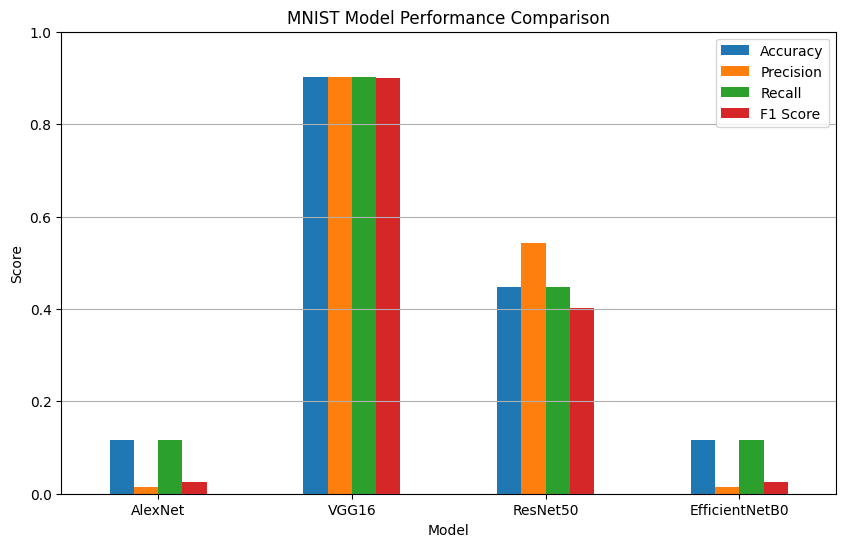

In [34]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("MNIST Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [35]:
predictions = efficient_model.predict(
    x_test[:10]
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("Actual labels   :", y_test[:10])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Actual labels   : [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]


In [36]:
predictions = efficient_model.predict(
    x_test[:10]
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("Actual labels   :", y_test[:10])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Actual labels   : [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]


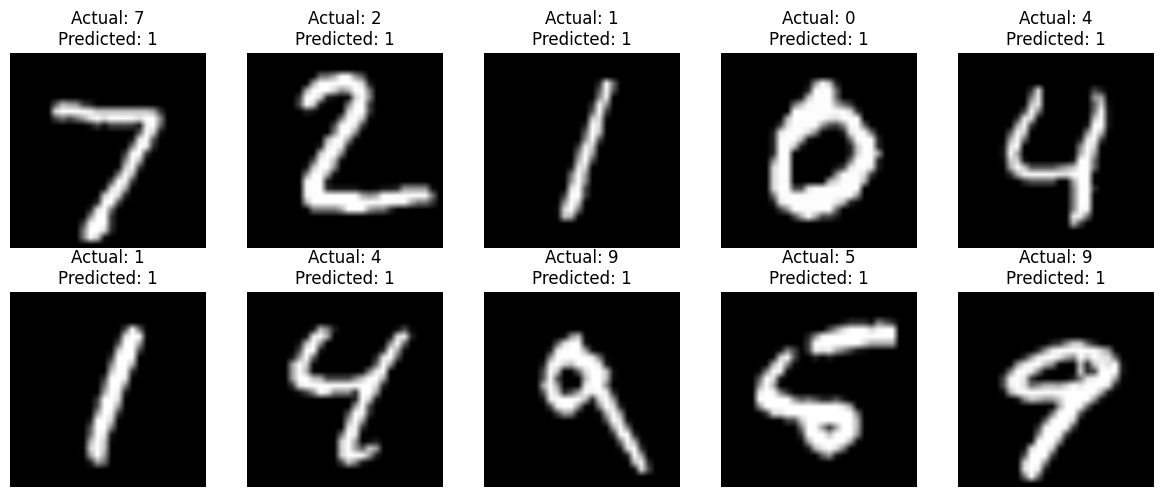

In [37]:
plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # Display first channel because image is RGB
    plt.imshow(
        x_test[i][:, :, 0],
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()